## Задание 1
Вычислите интегралы методом Монте-Карло, пользуясь формулами
$$\int_{a_1}^{b_1} \int_{a_2}^{b_2} \cdots \int_{a_m}^{b_m} f\!\left(x^1, x^2, \ldots, x^m\right) dx^1\, dx^2 \cdots dx^m \approx \frac{(b_1 - a_1)(b_2 - a_2)\cdots(b_m - a_m)}{N} \sum_{i=1}^{N} f\!\left(x_i^1, x_i^2, \ldots, x_i^m\right)$$
### Вариант 16
$$I = \int_0^1 \int_1^2 \int_0^3 \frac{xyz}{4} \, dx\, dy\, dz$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a1, b1 = 0, 3
a2, b2 = 1, 2
a3, b3 = 0, 1

def f(x, y, z):
    return x * y * z / 4

volume = (b1 - a1) * (b2 - a2) * (b3 - a3)
print(f"Область интегрирования: x ∈ [{a1}, {b1}], y ∈ [{a2}, {b2}], z ∈ [{a3}, {b3}]")

Область интегрирования: x ∈ [0, 3], y ∈ [1, 2], z ∈ [0, 1]


In [2]:
exact = (1/4) * (b1**2 - a1**2)/2 * (b2**2 - a2**2)/2 * (b3**2 - a3**2)/2
print(f"Точное значение интеграла для сравнения: {exact:.6f}")

Точное значение интеграла для сравнения: 0.843750


## Вычисление методом Монте-Карло

In [3]:
def monte_carlo_integral(N, seed=42):
    rng = np.random.default_rng(seed)
    
    x = rng.uniform(a1, b1, N)
    y = rng.uniform(a2, b2, N)
    z = rng.uniform(a3, b3, N)
    
    I = volume * np.mean(f(x, y, z))
    return I

N = 1_000_000
result = monte_carlo_integral(N)

print(f"N = {N:,}")
print(f"Результат МК:         {result:.6f}")
print(f"Точное значение:      {exact:.6f}")
print(f"Абсолютная погрешность: {abs(result - exact):.6f}")
print(f"Относительная погрешность: {abs(result - exact)/exact * 100:.4f}%")

N = 1,000,000
Результат МК:         0.843308
Точное значение:      0.843750
Абсолютная погрешность: 0.000442
Относительная погрешность: 0.0524%


## Сходимость метода при увеличении N

In [4]:
N_values = [10, 50, 100, 500, 1_000, 5_000, 10_000,
            50_000, 100_000, 500_000, 1_000_000]

results = [monte_carlo_integral(N) for N in N_values]
errors  = [abs(r - exact) for r in results]

print(f"{'N':>12}  {'Результат МК':>14}  {'Погрешность|':>15}")
print("-" * 46)
for N, r, e in zip(N_values, results, errors):
    print(f"{N:>12,}  {r:>14.6f}  {e:>15.6f}")
print(f"\nТочное значение: {exact:.6f}")

           N    Результат МК     Погрешность|
----------------------------------------------
          10        1.141928         0.298178
          50        0.832458         0.011292
         100        0.754059         0.089691
         500        0.823252         0.020498
       1,000        0.828335         0.015415
       5,000        0.844899         0.001149
      10,000        0.841634         0.002116
      50,000        0.846288         0.002538
     100,000        0.846113         0.002363
     500,000        0.842381         0.001369
   1,000,000        0.843308         0.000442

Точное значение: 0.843750


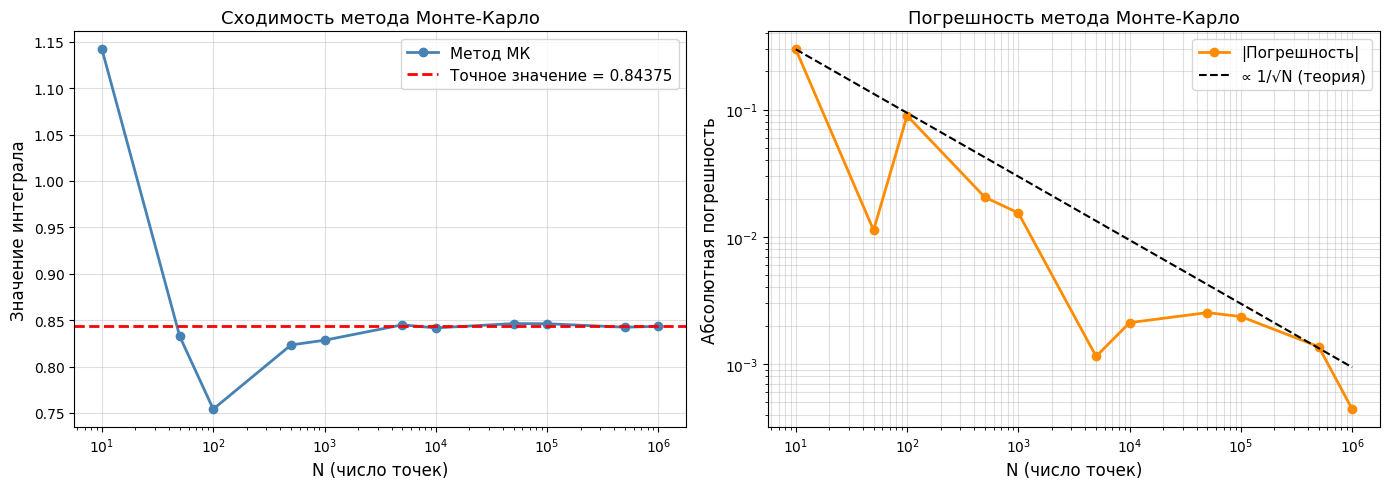

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(N_values, results, 'o-', color='steelblue',
                 linewidth=2, markersize=6, label='Метод МК')
axes[0].axhline(exact, color='red', linestyle='--', linewidth=2,
                label=f'Точное значение = {exact:.5f}')
axes[0].set_xlabel('N (число точек)', fontsize=12)
axes[0].set_ylabel('Значение интеграла', fontsize=12)
axes[0].set_title('Сходимость метода Монте-Карло', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

axes[1].loglog(N_values, errors, 'o-', color='darkorange',
               linewidth=2, markersize=6, label='|Погрешность|')
N_arr = np.array(N_values, dtype=float)
theory = errors[0] * np.sqrt(N_values[0]) / np.sqrt(N_arr)
axes[1].loglog(N_values, theory, 'k--', linewidth=1.5, label='∝ 1/√N (теория)')
axes[1].set_xlabel('N (число точек)', fontsize=12)
axes[1].set_ylabel('Абсолютная погрешность', fontsize=12)
axes[1].set_title('Погрешность метода Монте-Карло', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4, which='both')

plt.tight_layout()

## Задание 2
Решите систему линейных уравнений
$$
\left\{
\begin{aligned}
x_1 &= \alpha_{11} x_1 + \alpha_{12} x_2 + \beta_1 \\
x_2 &= \alpha_{21} x_1 + \alpha_{22} x_2 + \beta_2
\end{aligned}
\right.
$$
методом Монте-Карло
### Вариант 16
$$
\alpha_{11} = 0{,}5, \\
\alpha_{12} = 0{,}1, \\
\alpha_{21} = 0{,}1, \\
\alpha_{22} = 0{,}5, \\
\beta_1 = 0{,}4, \\
\beta_2 = 0{,}3
$$


In [6]:
import numpy as np

alpha = np.array([
    [0.5, 0.1],
    [0.1, 0.5]
])
beta = np.array([0.4, 0.3])
n = len(beta)

norm_alpha = np.max(np.sum(np.abs(alpha), axis=1))
print(f"Матрица alpha:")
print(alpha)
print(f"\nВектор beta: {beta}")
print(f"\nСтрочная норма ||alpha|| = {norm_alpha:.4f}")
print(f"Условие сходимости ||alpha|| < 1: {'выполнено' if norm_alpha < 1 else 'не выполнено'}")

Матрица alpha:
[[0.5 0.1]
 [0.1 0.5]]

Вектор beta: [0.4 0.3]

Строчная норма ||alpha|| = 0.6000
Условие сходимости ||alpha|| < 1: выполнено


In [7]:
I = np.eye(n)
x_exact = np.linalg.solve(I - alpha, beta)
print(f"Точное решение:")
print(f"  x1 = {x_exact[0]:.6f}")
print(f"  x2 = {x_exact[1]:.6f}")

Точное решение:
  x1 = 0.958333
  x2 = 0.791667


In [8]:
def monte_carlo_linear_system(alpha, beta, N, start_state, seed=42):
    rng = np.random.default_rng(seed)
    n = len(beta)
    p = np.abs(alpha)
    
    v = np.zeros_like(alpha)
    mask = p > 0
    v[mask] = alpha[mask] / p[mask]
    
    total = 0.0
    
    for _ in range(N):
        state = start_state
        X = beta[state]
        weight = 1.0
        
        while True:
            xi = rng.random()
            
            cumsum = 0.0
            next_state = None
            for j in range(n):
                cumsum += p[state, j]
                if xi < cumsum:
                    next_state = j
                    break
            
            if next_state is None:
                break
            
            weight *= v[state, next_state]
            X += weight * beta[next_state]
            state = next_state
        
        total += X
    
    return total / N


N = 10_000
x1_mc = monte_carlo_linear_system(alpha, beta, N, start_state=0, seed=42)
x2_mc = monte_carlo_linear_system(alpha, beta, N, start_state=1, seed=123)

print(f"Метод Монте-Карло (N = {N:,}):")
print(f"  x1 ≈ {x1_mc:.6f}  (точное: {x_exact[0]:.6f}, погрешность: {abs(x1_mc - x_exact[0]):.6f})")
print(f"  x2 ≈ {x2_mc:.6f}  (точное: {x_exact[1]:.6f}, погрешность: {abs(x2_mc - x_exact[1]):.6f})")

Метод Монте-Карло (N = 10,000):
  x1 ≈ 0.951700  (точное: 0.958333, погрешность: 0.006633)
  x2 ≈ 0.803680  (точное: 0.791667, погрешность: 0.012013)


In [9]:
import matplotlib.pyplot as plt

N_values = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000]

results_x1, results_x2 = [], []
errors_x1, errors_x2 = [], []

for N in N_values:
    r1 = monte_carlo_linear_system(alpha, beta, N, start_state=0, seed=42)
    r2 = monte_carlo_linear_system(alpha, beta, N, start_state=1, seed=123)
    results_x1.append(r1)
    results_x2.append(r2)
    errors_x1.append(abs(r1 - x_exact[0]))
    errors_x2.append(abs(r2 - x_exact[1]))

print(f"{'N':>10} | {'x1 (МК)':>12} | {'x2 (МК)':>12} | {'|err x1|':>12} | {'|err x2|':>12}")
print("-" * 68)
for i, N in enumerate(N_values):
    print(f"{N:>10,} | {results_x1[i]:>12.6f} | {results_x2[i]:>12.6f} | "
          f"{errors_x1[i]:>12.6f} | {errors_x2[i]:>12.6f}")
print("-" * 68)
print(f"{'Точное':>10} | {x_exact[0]:>12.6f} | {x_exact[1]:>12.6f} |")

         N |      x1 (МК) |      x2 (МК) |     |err x1| |     |err x2|
--------------------------------------------------------------------
       100 |     0.966000 |     0.854000 |     0.007667 |     0.062333
       300 |     0.959333 |     0.795000 |     0.001000 |     0.003333
     1,000 |     0.971100 |     0.825700 |     0.012767 |     0.034033
     3,000 |     0.976600 |     0.817867 |     0.018267 |     0.026200
    10,000 |     0.951700 |     0.803680 |     0.006633 |     0.012013
    30,000 |     0.952120 |     0.794710 |     0.006213 |     0.003043
   100,000 |     0.956374 |     0.790702 |     0.001959 |     0.000965
--------------------------------------------------------------------
    Точное |     0.958333 |     0.791667 |


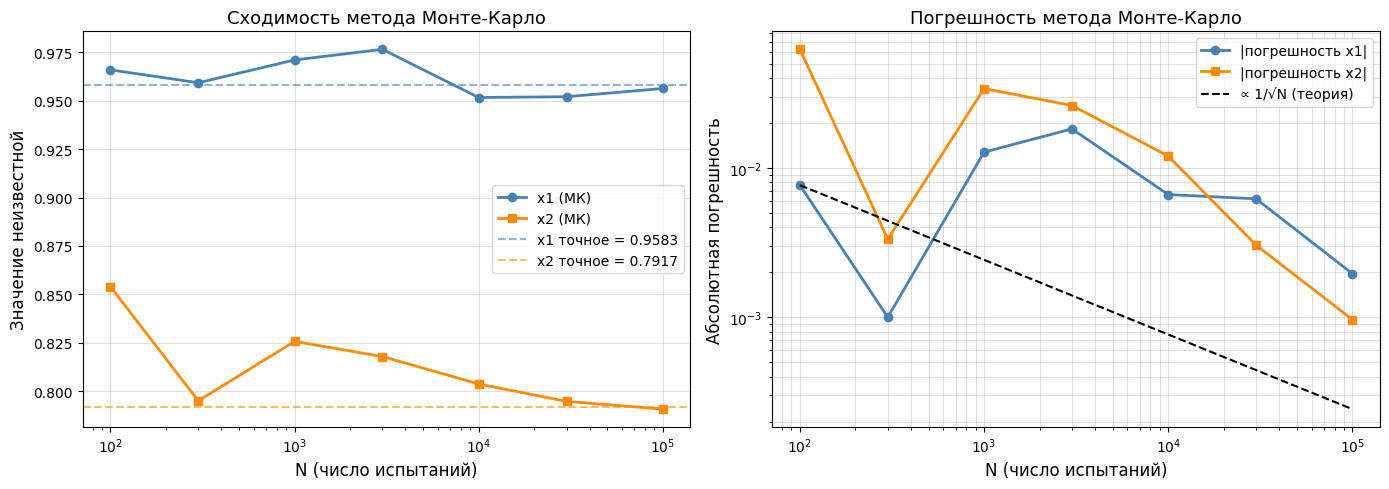

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(N_values, results_x1, 'o-', color='steelblue',
                 linewidth=2, markersize=6, label='x1 (МК)')
axes[0].semilogx(N_values, results_x2, 's-', color='darkorange',
                 linewidth=2, markersize=6, label='x2 (МК)')
axes[0].axhline(x_exact[0], color='steelblue', linestyle='--', linewidth=1.5,
                alpha=0.6, label=f'x1 точное = {x_exact[0]:.4f}')
axes[0].axhline(x_exact[1], color='darkorange', linestyle='--', linewidth=1.5,
                alpha=0.6, label=f'x2 точное = {x_exact[1]:.4f}')
axes[0].set_xlabel('N (число испытаний)', fontsize=12)
axes[0].set_ylabel('Значение неизвестной', fontsize=12)
axes[0].set_title('Сходимость метода Монте-Карло', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

N_arr = np.array(N_values, dtype=float)
axes[1].loglog(N_values, errors_x1, 'o-', color='steelblue',
               linewidth=2, markersize=6, label='|погрешность x1|')
axes[1].loglog(N_values, errors_x2, 's-', color='darkorange',
               linewidth=2, markersize=6, label='|погрешность x2|')
theory = errors_x1[0] * np.sqrt(N_values[0]) / np.sqrt(N_arr)
axes[1].loglog(N_values, theory, 'k--', linewidth=1.5, label='∝ 1/√N (теория)')
axes[1].set_xlabel('N (число испытаний)', fontsize=12)
axes[1].set_ylabel('Абсолютная погрешность', fontsize=12)
axes[1].set_title('Погрешность метода Монте-Карло', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4, which='both')

plt.tight_layout()
plt.show()

## Задание 3
Составьте программу определения площади фигуры методом Монте-Карло и вычислите её.
Постройте заданную фигуру.

### Вариант 16

Фигура задаётся системой неравенств:
$$\begin{cases}
-x^3 + y^5 < 2 \\
x - y < 1 \\
-2 < x < 2 \\
-2 < y < 2
\end{cases}$$

Ограничивающий прямоугольник: $x \in [-2,\,2]$, $y \in [-2,\,2]$, площадь $S_{\text{прям}} = 4 \times 4 = 16$.

Приближённая площадь вычисляется по формуле:
$$S \approx S_{\text{прям}} \cdot \frac{K}{N}$$
где $K$ — число точек, попавших внутрь фигуры, $N$ — общее число точек.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

x_min, x_max = -2, 2
y_min, y_max = -2, 2
S_rect = (x_max - x_min) * (y_max - y_min)  # = 16

def inside(x, y):
    """Возвращает булев массив: True если точка (x, y) внутри фигуры."""
    return (
        (-x**3 + y**5 < 2) &
        (x - y < 1)
    )

print(f"Ограничивающий прямоугольник: x ∈ [{x_min}, {x_max}], y ∈ [{y_min}, {y_max}]")
print(f"Площадь прямоугольника S_прям = {S_rect}")

Ограничивающий прямоугольник: x ∈ [-2, 2], y ∈ [-2, 2]
Площадь прямоугольника S_прям = 16


In [ ]:
N = 100_000
rng = np.random.default_rng(42)

x = rng.uniform(x_min, x_max, N)
y = rng.uniform(y_min, y_max, N)

mask = inside(x, y)
K = np.sum(mask)

S_approx = S_rect * K / N

S_ref = 6.573072

abs_err = abs(S_approx - S_ref)
rel_err = abs_err / S_ref * 100

print(f"Число случайных точек:        N = {N:,}")
print(f"Число точек внутри фигуры:    K = {K:,}")
print(f"Площадь прямоугольника: S_прям = {S_rect}")
print(f"")
print(f"S ≈ S_прям · K/N = {S_rect} · {K}/{N}")
print(f"S ≈ {S_approx:.6f}")
print(f"")
print(f"Эталонное значение (N=10⁷):   S_ref  = {S_ref:.6f}")
print(f"Абсолютная погрешность:        |ΔS|   = {abs_err:.6f}")
print(f"Относительная погрешность:      δS    = {rel_err:.4f}%")

Число случайных точек:        N = 100,000
Число точек внутри фигуры:    K = 40,845
Площадь прямоугольника: S_прям = 16

S ≈ S_прям · K/N = 16 · 40845/100000
S ≈ 6.535200

Эталонное значение (N=10⁷):   S_ref  = 6.573072
Абсолютная погрешность:        |ΔS|   = 0.037872
Относительная погрешность:      δS    = 0.5762%


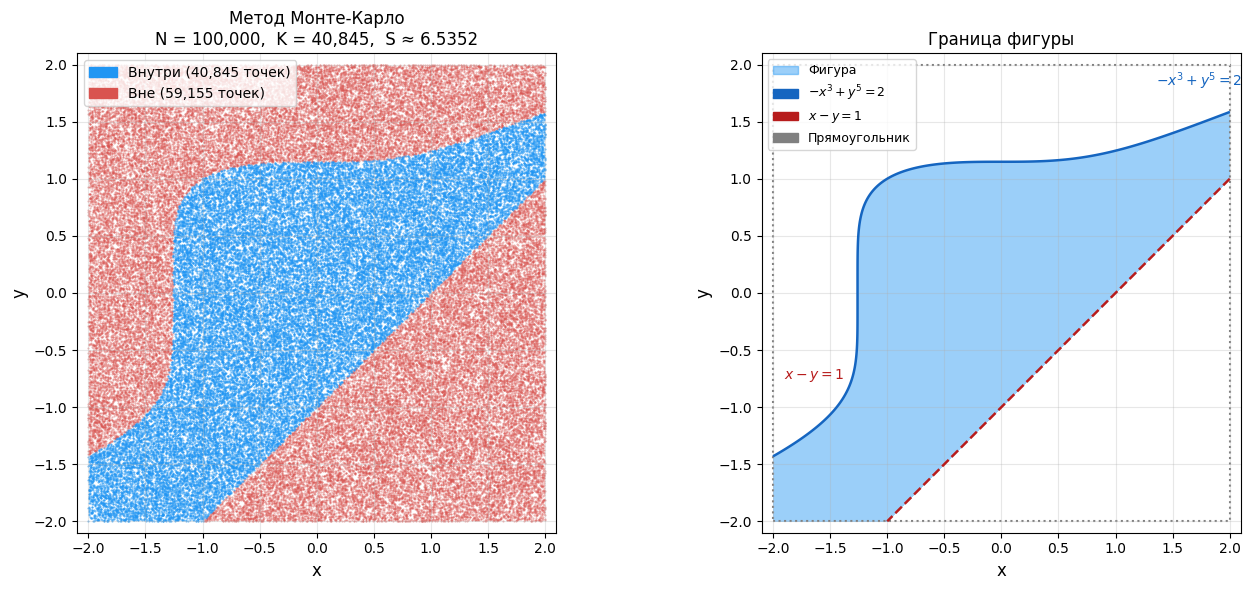

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(x[~mask], y[~mask], s=0.3, color='#d9534f', alpha=0.4, label='Вне фигуры')
ax.scatter(x[mask],  y[mask],  s=0.3, color='#2196F3', alpha=0.6, label='Внутри фигуры')
ax.set_xlim(x_min - 0.1, x_max + 0.1)
ax.set_ylim(y_min - 0.1, y_max + 0.1)
ax.set_aspect('equal')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title(f'Метод Монте-Карло\nN = {N:,},  K = {K:,},  S ≈ {S_approx:.4f}', fontsize=12)
blue_patch  = mpatches.Patch(color='#2196F3', label=f'Внутри ({K:,} точек)')
red_patch   = mpatches.Patch(color='#d9534f', label=f'Вне ({N-K:,} точек)')
ax.legend(handles=[blue_patch, red_patch], fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

ax2 = axes[1]
xs = np.linspace(x_min, x_max, 1000)
ys = np.linspace(y_min, y_max, 1000)
X, Y = np.meshgrid(xs, ys)
Z = inside(X, Y).astype(float)

ax2.contourf(X, Y, Z, levels=[0.5, 1.5], colors=['#2196F3'], alpha=0.45)
ax2.contour(X, Y, -X**3 + Y**5 - 2, levels=[0], colors=['#1565C0'], linewidths=1.8,
            linestyles='-')
ax2.contour(X, Y, X - Y - 1,        levels=[0], colors=['#b71c1c'], linewidths=1.8,
            linestyles='--')

# Подписи кривых
ax2.text(1.35, 1.95, r'$-x^3+y^5=2$', color='#1565C0', fontsize=10, va='top')
ax2.text(-1.9, -0.75, r'$x-y=1$',      color='#b71c1c', fontsize=10)

rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                      linewidth=1.5, edgecolor='gray', facecolor='none',
                      linestyle=':', label='Ограничивающий прямоугольник')
ax2.add_patch(rect)
ax2.set_xlim(x_min - 0.1, x_max + 0.1)
ax2.set_ylim(y_min - 0.1, y_max + 0.1)
ax2.set_aspect('equal')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Граница фигуры', fontsize=12)
blue_fill   = mpatches.Patch(color='#2196F3', alpha=0.45, label='Фигура')
blue_line   = mpatches.Patch(color='#1565C0', label=r'$-x^3+y^5=2$')
red_line    = mpatches.Patch(color='#b71c1c', label=r'$x-y=1$')
gray_line   = mpatches.Patch(color='gray',    label='Прямоугольник')
ax2.legend(handles=[blue_fill, blue_line, red_line, gray_line], fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

           N |     S (МК) |       |ΔS| |    δS, %
--------------------------------------------------
       1,000 |   6.576000 |   0.002928 |   0.0445
       3,000 |   6.762667 |   0.189595 |   2.8844
      10,000 |   6.545600 |   0.027472 |   0.4179
      30,000 |   6.652800 |   0.079728 |   1.2129
     100,000 |   6.535200 |   0.037872 |   0.5762
     300,000 |   6.574293 |   0.001221 |   0.0186
   1,000,000 |   6.572736 |   0.000336 |   0.0051
--------------------------------------------------
Эталон (10⁷) |   6.573072 |


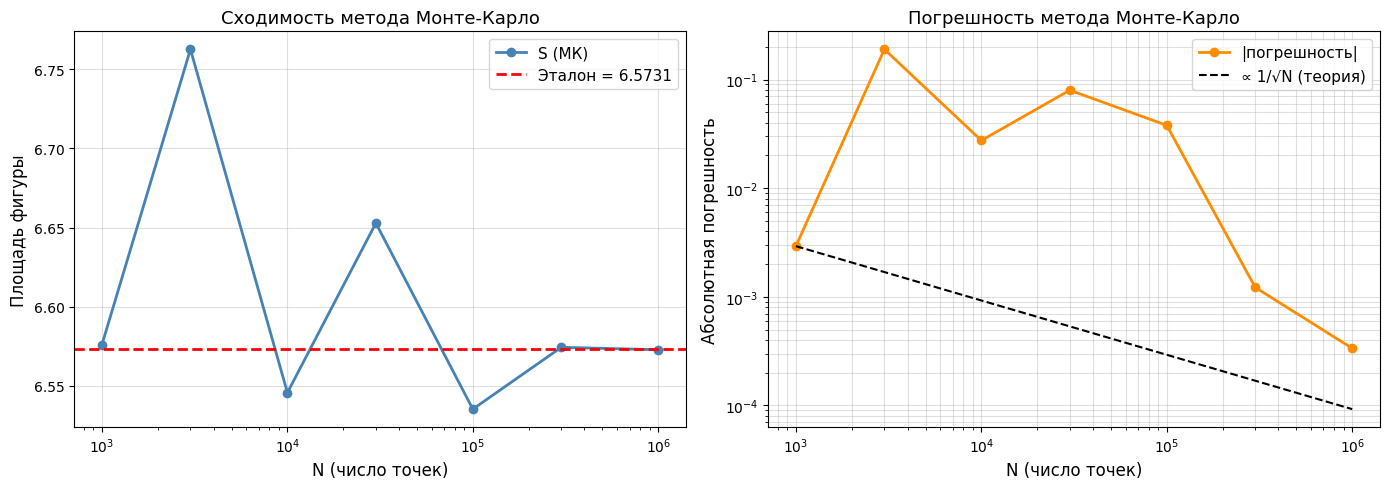

In [ ]:
N_values = [1_000, 3_000, 10_000, 30_000, 100_000, 300_000, 1_000_000]
S_values, err_values = [], []

for Ni in N_values:
    rng_i = np.random.default_rng(42)
    xi = rng_i.uniform(x_min, x_max, Ni)
    yi = rng_i.uniform(y_min, y_max, Ni)
    Ki = np.sum(inside(xi, yi))
    Si = S_rect * Ki / Ni
    S_values.append(Si)
    err_values.append(abs(Si - S_ref))

print(f"{'N':>12} | {'S (МК)':>10} | {'|ΔS|':>10} | {'δS, %':>8}")
print("-" * 50)
for Ni, Si, ei in zip(N_values, S_values, err_values):
    print(f"{Ni:>12,} | {Si:>10.6f} | {ei:>10.6f} | {ei/S_ref*100:>8.4f}")
print("-" * 50)
print(f"{'Эталон (10⁷)':>12} | {S_ref:>10.6f} |")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(N_values, S_values, 'o-', color='steelblue',
                 linewidth=2, markersize=6, label='S (МК)')
axes[0].axhline(S_ref, color='red', linestyle='--', linewidth=2,
                label=f'Эталон = {S_ref:.4f}')
axes[0].set_xlabel('N (число точек)', fontsize=12)
axes[0].set_ylabel('Площадь фигуры', fontsize=12)
axes[0].set_title('Сходимость метода Монте-Карло', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

N_arr = np.array(N_values, dtype=float)
axes[1].loglog(N_values, err_values, 'o-', color='darkorange',
               linewidth=2, markersize=6, label='|погрешность|')
theory = err_values[0] * np.sqrt(N_values[0]) / np.sqrt(N_arr)
axes[1].loglog(N_values, theory, 'k--', linewidth=1.5, label='∝ 1/√N (теория)')
axes[1].set_xlabel('N (число точек)', fontsize=12)
axes[1].set_ylabel('Абсолютная погрешность', fontsize=12)
axes[1].set_title('Погрешность метода Монте-Карло', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4, which='both')

plt.tight_layout()
plt.show()